**Project Overview**

This project builds an interactive Reddit-based campaign intelligence app focused on San Francisco. The app collects public posts from selected San Francisco-related subreddits, filters them for relevant places and local political or community issues, and then analyzes the tone of those conversations using a pretrained sentiment analysis model. The goal is to turn large amounts of unstructured Reddit discussion into a cleaner, more useful dataset that can support issue monitoring, public sentiment tracking, and campaign strategy development.

**Goal of the App**

The main goal of this app is to help identify **what people are talking about, how they feel about those topics, and which issues may deserve the most attention**. To do this, the pipeline:

Connects to Reddit in read-only mode
Pulls posts from multiple subreddit feeds such as new, hot, and top
Filters posts based on predefined place names and issue keywords
Labels posts with simple geographic and issue hints
Scores each post’s sentiment as negative, neutral, or positive
Aggregates the results into tables, trends, and priority rankings
Presents the findings in both a PDF report and an interactive Streamlit dashboard

**What the App Produces**

The app produces several outputs that make the Reddit data easier to interpret:

A cleaned dataset of relevant Reddit posts
Sentiment scores and sentiment labels for each post
A ranking of the most discussed issues
Daily sentiment trends over time
A summary of rising and falling issues
A priority view that highlights issues with high discussion volume and negative sentiment
A PDF report for sharing findings
An interactive dashboard for filtering and exploring results in real time

**Results and Value**

The result of this project is a working prototype that transforms Reddit conversations into a practical campaign insight tool. Instead of reading posts one by one, users can quickly see:

which issues are receiving the most attention,
which topics are generating more negative or positive reactions,
which posts are getting the strongest engagement,
and which issues may be the best candidates for campaign focus.

Overall, this app demonstrates how public Reddit discussions can be converted into a structured workflow for local political analysis, issue prioritization, and communication strategy support.

In [2]:

#installing a stack for data collection + NLP/ML + data handling. Package-by-package:
#praw – Python Reddit API Wrapper. Scrape/read Reddit posts/comments (auth via Reddit app).
#SQLAlchemy – Database toolkit/ORM. Define tables and read/write to SQLite/Postgres/MySQL, etc.
#transformers – Hugging Face library for state-of-the-art NLP models (BERT, RoBERTa, GPT-style, etc.).
#torch – PyTorch deep learning framework used by many transformers models for training/inference.
#ftfy – “Fixes Text For You.” Cleans up weird Unicode/encoding glitches in scraped text.
#unidecode – Transliterates Unicode to ASCII (e.g., “Résumé” → “Resume”) for normalization.
#langdetect – Detects the language of text; handy for filtering non-English content.
#pandas – DataFrames for loading/cleaning/joining/analyzing datasets.
#tqdm – Progress bars for loops and pandas apply operations.

!pip -q install praw SQLAlchemy transformers torch ftfy unidecode langdetect pandas tqdm

# progress bars in notebooks
from tqdm.auto import tqdm
tqdm.pandas()
print("✅ Installed.")

✅ Installed.


In [3]:
!pip -q install reportlab     # download and install the ReportLab Python package, which generate PDFs from code (pages, text, images, tables, simple graphics).

#When you run pip install, it normally prints lots of lines (downloading, building wheels, progress bars, etc.).
#Adding -q (quiet) hides most of that chatter so your notebook cell stays clean. You’ll still see warnings or errors if something goes wrong.

In [4]:
!pip -q install streamlit pyngrok

#pip install streamlit pyngrok → install:
#streamlit: builds a simple data/web apps in pure Python (buttons, sliders, charts).
#pyngrok: gives a local app a public URL (tunnels a local port to the internet).

In [5]:
!pip -q install gspread gspread_dataframe

#That command quietly installs two libraries for working with Google Sheets from Python:
#gspread – read, create, and edit Google Sheets (open a sheet, add a tab, write cells, etc.).
#gspread_dataframe – handy helpers to write a pandas DataFrame to a sheet (and read back) in one call.

In [6]:
# Initialize a read-only Reddit API connection with PRAW, then access r/sanfrancisco
# and print the titles of the first 5 posts from its “hot” feed. This cell sets up the
# client with the app credentials, ensures no write actions can be performed, and serves
# as a simple test to confirm the Reddit connection is working properly.

import praw #Load PRAW, the Reddit API library.

REDDIT_CLIENT_ID     = "fJ1lgfNeU6H6s2foxK_e1g"   # short ID under app name
REDDIT_CLIENT_SECRET = None
REDDIT_USER_AGENT    = "campaign-mvp-installed (by u/Crafty_Average_4875)"

reddit = praw.Reddit(
    client_id=REDDIT_CLIENT_ID,
    client_secret=REDDIT_CLIENT_SECRET,
    user_agent=REDDIT_USER_AGENT,
)
reddit.read_only = True

for i, p in enumerate(reddit.subreddit("sanfrancisco").hot(limit=5), 1):
    print(i, "-", p.title)
# The loop grabs the “hot” feed from r/sanfrancisco (limited to 5 posts) and prints each
# post’s number and title. `enumerate(..., 1)` gives nice human-friendly numbering starting
# at 1 (so 1, 2, 3, 4, 5). `p` is each post object, and `p.title` is the post’s


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



1 - Weekly Discussion - Lifting the Fog 🌁
2 - ICE already causing havoc at SFO
3 - ICE at SFO
4 - ICE agents seen 'terrorizing' woman and child at SFO, Calif. senator says
5 - Why is ICE at SFO in the first place?


In [7]:
# Shows the newest posts in strict time order (most recent first), 10 items.

for i, p in enumerate(reddit.subreddit("sanfrancisco").new(limit=10), 1):
    print(i, "-", p.title)

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



1 - Why were SF city police working with ICE at the airport? | Immigration arrest at SFO sparks concerns over potential breach of California's sanctuary law and San Francisco's sanctuary ordinance
2 - Parked Car in Chinatown scratched
3 - Weird Sign @ Equinox
4 - Walnut Creek woman arrested in SF crash that killed toddler
5 - Rampant and blatant rule breaking - what can we do?
6 - S.F. public health boss: Hospital staff stopped stabbing, not sheriff
7 - Sunset from a different part of town, on 22 floors built from compressed fill.
8 - SF is a "Sanctuary city"? The violent SFO detainment proves otherwise
9 - Chuck Norris Boulevard? San Francisco petition seeks to rename Cesar Chavez Street
10 - A quick timelapse of a waxing crescent moon setting over Salesforce Tower, glowing with “Day for Night” by Jim Campbell to mark the spring equinox 🌻🌞


In [8]:
# Most upvoted in a period (day/week/month/all).

for i, p in enumerate(reddit.subreddit("sanfrancisco").top(time_filter="month", limit=10), 1):
    print(i, "-", p.title)

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



1 - ICE already causing havoc at SFO
2 - Entire family kidnapped by ICE in SF. No comment from Mr. Mayor.
3 - ICE at SFO
4 - Moonrise from California St, 03/02/26
5 - Do better, people 🤬
6 - Sam Smith @ North Beach
7 - WE JUST RE-LAUNCHED THE BAY LIGHTS!
8 - Badass Lady In Scubs Rushing to Help Crash
9 - Got Lucky with the Blimp yesterday
10 - Ladies and gentlemen, my neighbors.


In [9]:
# Fetch and print the titles of the first 10 “rising” posts from r/sanfrancisco.
# The rising feed highlights posts that are starting to gain attention, making this
# useful for spotting newer content that may become popular soon.

for i, p in enumerate(reddit.subreddit("sanfrancisco").rising(limit=10), 1):
    print(i, "-", p.title)

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



1 - ICE agents seen 'terrorizing' woman and child at SFO, Calif. senator says
2 - If you want the SF Bay Area to remain an economic engine, here's another reason to not vote Chad Bianco
3 - Why is ICE at SFO in the first place?
4 - North Beach's Butter & Crumble hires staffer just to manage its three-block lines
5 - ICE already causing havoc at SFO
6 - ICE at SFO
7 - Hamburger Project responds saying delivery driver left product unattended and product was immediately discarded
8 - S.F. public health boss: Hospital staff stopped stabbing, not sheriff
9 - A quick timelapse of a waxing crescent moon setting over Salesforce Tower, glowing with “Day for Night” by Jim Campbell to mark the spring equinox 🌻🌞
10 - Walnut Creek woman arrested in SF crash that killed toddler


In [10]:
# Set up the Reddit data collection pipeline by importing the required libraries,
# connecting to Reddit in read-only mode, defining the target places, issues, and
# subreddits to monitor, building regex matchers for keyword detection, filtering
# posts that mention relevant locations or political/local issues, labeling them
# with simple geographic and issue hints, and storing the cleaned results in a
# pandas DataFrame for preview or optional export. :contentReference[oaicite:0]{index=0}

import praw, re, time
#praw: lets Python talk to Reddit (read posts, comments, etc.).
#re: used for text pattern matching (like searching keywords using regex).
#time: used to pause/wait between requests (helps avoid rate limits).

import pandas as pd
import logging #logging: controls how much “debug noise” libraries print.

# --- reuse your working creds ---
REDDIT_CLIENT_ID     = "fJ1lgfNeU6H6s2foxK_e1g"
REDDIT_CLIENT_SECRET = None
REDDIT_USER_AGENT    = "campaign-mvp-installed (by u/Crafty_Average_4875)"

# Quiet PRAW + prawcore loggers
logging.getLogger("praw").setLevel(logging.ERROR)
logging.getLogger("prawcore").setLevel(logging.ERROR)


reddit = praw.Reddit(
    client_id=REDDIT_CLIENT_ID,
    client_secret=REDDIT_CLIENT_SECRET,
    user_agent=REDDIT_USER_AGENT,
)
reddit.read_only = True


# Where to save the SQLite database + CSV
DB_PATH = "/content/campaign_mvp.sqlite"
CSV_PATH = "/content/processed_posts.csv"   #/content/... is a common Google Colab path.


# === SAN FRANCISCO: places/neighborhoods/nearby cities ===
PLACES = [
    "san francisco", "sf", "bay area", "mission district", "tenderloin",
    "sunset", "richmond district", "soma", "financial district", "nob hill",
    "pacific heights", "haight ashbury", "castro", "marina district", "north beach",
    "bernal heights", "dogpatch", "outer mission", "presidio", "potrero hill",
    "oakland", "berkeley", "daly city", "south san francisco"
]

#This is a list of political/local issues + names.
ISSUES = [
    "homelessness", "housing", "crime", "drug use", "fentanyl", "overdose",
    "public safety", "policing", "sanitation", "education", "schools",
    "transit", "muni", "bart", "traffic", "economy", "tech layoffs",
    "affordability", "cost of living", "climate", "environment",
    "immigration", "rent", "eviction", "small business", "local elections",
    "mayor", "daniel lurie", "board of supervisors", "donald trump",
    "nancy pelosi", "scott wiener",
    "ICE raid", "ICE raids", "ICE agents", "Immigration and Customs Enforcement",
    "ICE enforcement", "ICE detention"
]

#This is the list of subreddits the script plans to pull posts from.
SUBS = [
    # Local/Bay Area
    "sanfrancisco","bayarea","AskSF","oakland","berkeley","eastbay","SanJose","Fremont","Sacramento","Fresno",
    # California-wide
    "California","CaliforniaPolitics",
    # National / general politics
    "politics","PoliticalDiscussion","Ask_Politics","worldpolitics","elections","USPolitics",
    # Ideology / parties
    "Conservative","Liberal","Libertarian","Progressive","democrats","Republican","ModeratePolitics",
]
#Note:
# This builds two “big matchers” from my lists of places and issues. For phrases (terms with spaces), it matches the phrase exactly;
# for single words, it matches whole words only (so “bart” won’t hit “bartender”). Everything is case-insensitive.
# The result is two compiled regex matchers—PLACES_RE and ISSUES_RE—that I can use like PLACES_RE.search(text) or
#ISSUES_RE.search(text) to quickly check if any of my terms appear in a piece of text.


# The function `word_or_phrase_regex(words)` creates and returns a compiled regular
# expression that searches for any target word or phrase in Reddit text. Multi-word
# phrases are matched literally, while single-word terms are wrapped with word
# boundaries to avoid partial matches. The resulting regex is case-insensitive and
# efficient for repeated use across many posts.

def word_or_phrase_regex(words):    #This defines a function that takes a list called words.
    parts = []                      #parts starts as an empty list. You’ll fill it with little regex pieces.
    for w in words:                 #Loop through each word/phrase: Goes through each item w in your list.
        if " " in w:                    #If it’s a phrase (contains a space): Example: "mission district" or "ICE raids". For phrases, it just adds the phrase into the regex.
            parts.append(re.escape(w))  #re.escape(w) is important: it protects special characters.Example: if a phrase had . or ?, regex would normally treat those as “special.” re.escape turns them into normal text so it matches literally.
        else:                           # If it’s a single word (no spaces): Example: "sf" or "crime"
            parts.append(rf"\b{re.escape(w)}\b") #Here it adds word boundaries around it: \b ... \b Because you want to match the whole word, not a piece inside another word. f you're looking for "sf": without boundaries, it might match "SFO" or "transferring" with \b, it matches only when "sf" appears as its own word (surrounded by spaces/punctuation).So "crime" won’t accidentally match "crimes" unless you include "crimes" too.
    return re.compile("|".join(parts), re.IGNORECASE) #Combine all pieces into one big pattern. parts might become something like:["\bsf\b", "san\ francisco", "\bcrime\b", "ICE\ raids"]. "|".join(parts) combines them with the regex OR operator (|): meaning: match this OR that OR that...
                                                     # re.IGNORECASE means it matches regardless of uppercase/lowercase:
                                                     #re.compile(...) turns the pattern into a compiled regex object, which is faster to use repeatedly.


PLACES_RE = word_or_phrase_regex(PLACES)   #   PLACES_RE.search(text) -> does text mention ANY place?
ISSUES_RE = word_or_phrase_regex(ISSUES)   #   ISSUES_RE.search(text) -> does text mention ANY issue?


# capture more by default: place OR issue (change to AND if you want stricter)
def match_place_or_issue(title, body):
    t = f"{title or ''}\n{body or ''}"
    return bool(PLACES_RE.search(t) or ISSUES_RE.search(t))


# The function `first_hit_regex(text, words)` checks a piece of text against a list
# of target words or phrases and returns the first match it finds. Multi-word phrases
# are matched literally, while single-word terms use word boundaries to avoid partial
# matches, such as matching "ICE" inside "police". If no match is found, the function
# returns None.

def first_hit_regex(text, words):
    t = text or ""
    for w in words:
        if " " in w:
            rx = re.compile(re.escape(w), re.IGNORECASE)
        else:
            rx = re.compile(rf"\b{re.escape(w)}\b", re.IGNORECASE)
        if rx.search(t):
            return w
    return None


# This block loops through each subreddit in `SUBS`, collects posts from the new,
# hot, and top-of-year feeds, and keeps only the posts that match at least one
# target place or issue term. For each matching post, it creates a structured row
# with post details, engagement metrics, and simple labels (`geo_hint` and
# `issue_hint`) based on the first matching place and issue found in the text.
# The collected rows are stored in `rows`, while a short delay helps avoid making
# requests to Reddit too quickly.

rows = []
for sub in SUBS:
    s = reddit.subreddit(sub)
    streams = [
        ("new", s.new(limit=400)),
        ("hot", s.hot(limit=200)),  # smaller because hot overlaps with new/top a lot
        ("top_year", s.top(time_filter="year", limit=400)),
    ]
    for label, gen in streams:
        for post in gen:
            title = post.title or ""
            body  = post.selftext or ""
            if not match_place_or_issue(title, body):
                continue
            text = (title + "\n" + body).strip()
            rows.append({
                "subreddit": sub,
                "created_utc": int(post.created_utc or 0),
                "title": title,
                "body": body,
                "text": text,
                "permalink": f"https://reddit.com{post.permalink}",
                "score": int(post.score or 0),
                "num_comments": int(post.num_comments or 0),
                "geo_hint": first_hit_regex(text, PLACES),
                "issue_hint": first_hit_regex(text, ISSUES),
            })
        time.sleep(0.2)
    print(f"scanned r/{sub} → total kept so far: {len(rows)}")

# Convert the collected `rows` into a pandas DataFrame, remove duplicate posts
# using the permalink, reset the index, and preview the cleaned results. This
# produces a unique table of matched Reddit posts and prints the total number
# of posts kept after deduplication.

df = pd.DataFrame(rows).drop_duplicates(subset=["permalink"]).reset_index(drop=True)
print("✅ fetched rows:", len(df))
df.head(5)


scanned r/sanfrancisco → total kept so far: 440
scanned r/bayarea → total kept so far: 905
scanned r/AskSF → total kept so far: 1542
scanned r/oakland → total kept so far: 2062
scanned r/berkeley → total kept so far: 2519
scanned r/eastbay → total kept so far: 2886
scanned r/SanJose → total kept so far: 3039
scanned r/Fremont → total kept so far: 3180
scanned r/Sacramento → total kept so far: 3256
scanned r/Fresno → total kept so far: 3351
scanned r/California → total kept so far: 3518
scanned r/CaliforniaPolitics → total kept so far: 3585
scanned r/politics → total kept so far: 3678
scanned r/PoliticalDiscussion → total kept so far: 3937
scanned r/Ask_Politics → total kept so far: 4040
scanned r/worldpolitics → total kept so far: 4041
scanned r/elections → total kept so far: 4154
scanned r/USPolitics → total kept so far: 4243
scanned r/Conservative → total kept so far: 4297
scanned r/Liberal → total kept so far: 4424
scanned r/Libertarian → total kept so far: 4489
scanned r/Progressiv

,subreddit,created_utc,title,body,text,permalink,score,num_comments,geo_hint,issue_hint
0,sanfrancisco,1774311315,Why were SF city police working with ICE at th...,,Why were SF city police working with ICE at th...,https://reddit.com/r/sanfrancisco/comments/1s1...,13,6,san francisco,immigration
1,sanfrancisco,1774309858,Walnut Creek woman arrested in SF crash that k...,"Merih Fssha Solomon, 47, of Walnut Creek was a...",Walnut Creek woman arrested in SF crash that k...,https://reddit.com/r/sanfrancisco/comments/1s1...,42,12,sf,None
2,sanfrancisco,1774307873,Rampant and blatant rule breaking - what can w...,I was very glad to see this post a few days ag...,Rampant and blatant rule breaking - what can w...,https://reddit.com/r/sanfrancisco/comments/1s1...,15,27,soma,traffic
3,sanfrancisco,1774300285,"Sunset from a different part of town, on 22 fl...","When it quakes, your whole world moves with … ...","Sunset from a different part of town, on 22 fl...",https://reddit.com/r/sanfrancisco/comments/1s1...,4,1,sunset,None
4,sanfrancisco,1774300265,"SF is a ""Sanctuary city""? The violent SFO deta...","Hey all, [Eddie Kim](http://eddiekim.net/) fro...","SF is a ""Sanctuary city""? The violent SFO deta...",https://reddit.com/r/sanfrancisco/comments/1s1...,0,3,sf,immigration


In [15]:
# Load the pretrained RoBERTa sentiment model and tokenizer, then score each post’s
# text in batches to measure sentiment. For every Reddit post, this block assigns a
# numeric sentiment score and a sentiment label (negative, neutral, or positive),
# saves the updated DataFrame to a CSV file, and previews the first 10 rows of the
# final sentiment-scored dataset.

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import numpy as np

CSV_PATH = "/content/processed_posts_sf.csv"
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"

if len(df) == 0:
    print("No rows to score. Consider loosening keywords or adding more subreddits.")
else:
    print("Loading tokenizer...")
    tok = AutoTokenizer.from_pretrained(MODEL_NAME)

    print("Loading model...")
    mdl = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
    mdl = mdl.to("cpu")
    mdl.eval()
    print("Ready.")

    def score_batch(texts, maxlen=256):
        enc = tok(list(texts), padding=True, truncation=True, max_length=maxlen, return_tensors="pt")
        with torch.no_grad():
            logits = mdl(**enc).logits
        probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()  # [neg, neu, pos]
        neg = probs[:, 0]
        pos = probs[:, 2]
        score = pos - neg  # [-1, 1]
        label = np.array(["neg", "neu", "pos"])[probs.argmax(axis=1)]
        return score, label

    scores, labels = [], []
    batch = 64

    for i in range(0, len(df), batch):
        print(f"Scoring rows {i} to {min(i + batch, len(df))} of {len(df)}")
        sc, lb = score_batch(df["text"].iloc[i:i+batch])
        scores.extend(sc)
        labels.extend(lb)

    df["sentiment_score"] = scores
    df["sentiment_label"] = labels
    df.to_csv(CSV_PATH, index=False, encoding="utf-8")
    print(f"✅ saved: {CSV_PATH} | rows: {len(df)}")

df.head(10)

Loading tokenizer...
Loading model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Ready.
Scoring rows 0 to 64 of 3609
Scoring rows 64 to 128 of 3609
Scoring rows 128 to 192 of 3609
Scoring rows 192 to 256 of 3609
Scoring rows 256 to 320 of 3609
Scoring rows 320 to 384 of 3609
Scoring rows 384 to 448 of 3609
Scoring rows 448 to 512 of 3609
Scoring rows 512 to 576 of 3609
Scoring rows 576 to 640 of 3609
Scoring rows 640 to 704 of 3609
Scoring rows 704 to 768 of 3609
Scoring rows 768 to 832 of 3609
Scoring rows 832 to 896 of 3609
Scoring rows 896 to 960 of 3609
Scoring rows 960 to 1024 of 3609
Scoring rows 1024 to 1088 of 3609
Scoring rows 1088 to 1152 of 3609
Scoring rows 1152 to 1216 of 3609
Scoring rows 1216 to 1280 of 3609
Scoring rows 1280 to 1344 of 3609
Scoring rows 1344 to 1408 of 3609
Scoring rows 1408 to 1472 of 3609
Scoring rows 1472 to 1536 of 3609
Scoring rows 1536 to 1600 of 3609
Scoring rows 1600 to 1664 of 3609
Scoring rows 1664 to 1728 of 3609
Scoring rows 1728 to 1792 of 3609
Scoring rows 1792 to 1856 of 3609
Scoring rows 1856 to 1920 of 3609
Scoring 

,subreddit,created_utc,title,body,text,permalink,score,num_comments,geo_hint,issue_hint,sentiment_score,sentiment_label
0,sanfrancisco,1774311315,Why were SF city police working with ICE at th...,,Why were SF city police working with ICE at th...,https://reddit.com/r/sanfrancisco/comments/1s1...,13,6,san francisco,immigration,-0.266671,neu
1,sanfrancisco,1774309858,Walnut Creek woman arrested in SF crash that k...,"Merih Fssha Solomon, 47, of Walnut Creek was a...",Walnut Creek woman arrested in SF crash that k...,https://reddit.com/r/sanfrancisco/comments/1s1...,42,12,sf,None,-0.736569,neg
2,sanfrancisco,1774307873,Rampant and blatant rule breaking - what can w...,I was very glad to see this post a few days ag...,Rampant and blatant rule breaking - what can w...,https://reddit.com/r/sanfrancisco/comments/1s1...,15,27,soma,traffic,-0.604962,neg
3,sanfrancisco,1774300285,"Sunset from a different part of town, on 22 fl...","When it quakes, your whole world moves with … ...","Sunset from a different part of town, on 22 fl...",https://reddit.com/r/sanfrancisco/comments/1s1...,4,1,sunset,None,0.019560,neu
4,sanfrancisco,1774300265,"SF is a ""Sanctuary city""? The violent SFO deta...","Hey all, [Eddie Kim](http://eddiekim.net/) fro...","SF is a ""Sanctuary city""? The violent SFO deta...",https://reddit.com/r/sanfrancisco/comments/1s1...,0,3,sf,immigration,-0.433728,neu
5,sanfrancisco,1774291516,Chuck Norris Boulevard? San Francisco petition...,"Chuck Norris cannot die, he fights for justice...",Chuck Norris Boulevard? San Francisco petition...,https://reddit.com/r/sanfrancisco/comments/1s1...,0,25,san francisco,None,0.137431,neu
6,sanfrancisco,1774287176,The San Francisco Public Utilities Commission ...,,The San Francisco Public Utilities Commission ...,https://reddit.com/r/sanfrancisco/comments/1s1...,1,0,san francisco,None,0.051534,neu
7,sanfrancisco,1774286889,Recommendations of San Francisco’s Commission ...,,Recommendations of San Francisco’s Commission ...,https://reddit.com/r/sanfrancisco/comments/1s1...,0,1,san francisco,None,0.049735,neu
8,sanfrancisco,1774285777,BART: The worst-case scenarios are actually wo...,,BART: The worst-case scenarios are actually wo...,https://reddit.com/r/sanfrancisco/comments/1s1...,143,176,None,bart,-0.774877,neg
9,sanfrancisco,1774285283,ICE agents seen 'terrorizing' woman and child ...,,ICE agents seen 'terrorizing' woman and child ...,https://reddit.com/r/sanfrancisco/comments/1s1...,604,105,None,ICE agents,-0.576893,neg


In [16]:
# Load the saved Reddit dataset from the CSV file, perform basic cleanup, and prepare
# the data for analysis. This block fills missing issue labels with "other", converts
# the Unix timestamp into readable datetime and date columns, removes posts with very
# little text, and previews the cleaned dataset.

from datetime import datetime

CSV_PATH = "/content/processed_posts_sf.csv"
df = pd.read_csv(CSV_PATH)

# Basic cleanup
df["issue"] = df["issue_hint"].fillna("other")
df["created_dt"] = pd.to_datetime(df["created_utc"], unit="s")
df["date"] = df["created_dt"].dt.date

# Keep only posts with some text
df = df[df["text"].astype(str).str.len() > 10].copy()
print("rows:", len(df), "| unique issues:", df["issue"].nunique())
df.head(3)


rows: 3605 | unique issues: 36


,subreddit,created_utc,title,body,text,permalink,score,num_comments,geo_hint,issue_hint,sentiment_score,sentiment_label,issue,created_dt,date
0,sanfrancisco,1774311315,Why were SF city police working with ICE at th...,NaN,Why were SF city police working with ICE at th...,https://reddit.com/r/sanfrancisco/comments/1s1...,13,6,san francisco,immigration,-0.266671,neu,immigration,2026-03-24 00:15:15,2026-03-24
1,sanfrancisco,1774309858,Walnut Creek woman arrested in SF crash that k...,"Merih Fssha Solomon, 47, of Walnut Creek was a...",Walnut Creek woman arrested in SF crash that k...,https://reddit.com/r/sanfrancisco/comments/1s1...,42,12,sf,NaN,-0.736569,neg,other,2026-03-23 23:50:58,2026-03-23
2,sanfrancisco,1774307873,Rampant and blatant rule breaking - what can w...,I was very glad to see this post a few days ag...,Rampant and blatant rule breaking - what can w...,https://reddit.com/r/sanfrancisco/comments/1s1...,15,27,soma,traffic,-0.604962,neg,traffic,2026-03-23 23:17:53,2026-03-23


In [17]:
# Count how often each issue appears in the cleaned dataset, sort the issues by the
# number of mentions, and keep the top 15 most frequently discussed topics. The
# result is stored in `top_issues` as a summary table with each issue and its
# corresponding mention count.

top_issues = (
    df["issue"]
    .value_counts()
    .head(15)
    .rename_axis("issue")
    .reset_index(name="mentions")
)
top_issues

,issue,mentions
0,other,1747
1,donald trump,280
2,immigration,171
3,housing,148
4,economy,132
5,rent,121
6,mayor,103
7,crime,102
8,traffic,101
9,schools,100


In [18]:
# Create a pivot table that summarizes how many posts for each of the top issues
# were labeled as negative, neutral, or positive. The table is ordered to match
# the ranking in `top_issues`, making it easier to compare sentiment patterns
# across the most frequently discussed topics.

pivot = (
    df.pivot_table(index="issue", columns="sentiment_label", values="text", aggfunc="count", fill_value=0)
    .loc[top_issues["issue"]]
)
pivot

sentiment_label,neg,neu,pos
issue,,,
other,321,914,512
donald trump,117,156,7
immigration,68,100,3
housing,24,105,19
economy,67,55,10
rent,27,80,14
mayor,28,59,16
crime,48,45,9
traffic,51,40,10


In [19]:
# Group the posts by date and calculate the average sentiment score for each day.
# This creates a simple time-series table, `trend`, that shows how overall Reddit
# sentiment changes over time, with the average sentiment stored in the
# `avg_sentiment` column.

trend = (
    df.groupby("date")["sentiment_score"]
    .mean()
    .reset_index()
    .rename(columns={"sentiment_score":"avg_sentiment"})
)
trend.tail(10)

,date,avg_sentiment
506,2026-03-15,-0.009622
507,2026-03-16,-0.002762
508,2026-03-17,-0.008338
509,2026-03-18,0.035607
510,2026-03-19,-0.006145
511,2026-03-20,0.081127
512,2026-03-21,0.040714
513,2026-03-22,0.007661
514,2026-03-23,-0.009680
515,2026-03-24,-0.062339


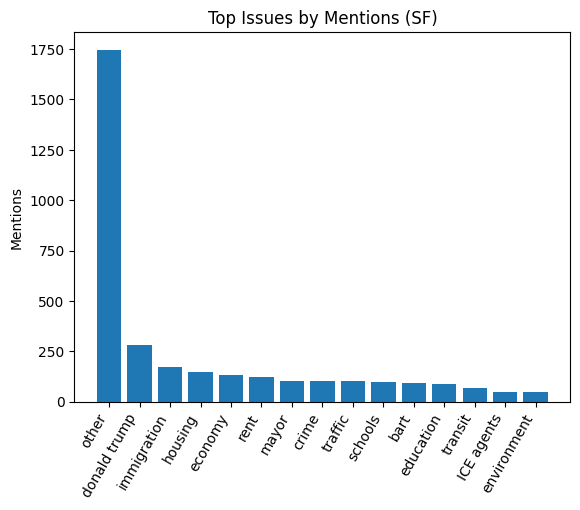

In [20]:
import matplotlib.pyplot as plt

# Top issues bar
ti = top_issues.copy()
plt.figure()
plt.bar(ti["issue"], ti["mentions"])
plt.xticks(rotation=60, ha="right")
plt.title("Top Issues by Mentions (SF)")
plt.ylabel("Mentions")
plt.show()

In [21]:
# Identify the five most frequently mentioned issues, define a helper function
# `top_posts(issue, n=5)` to retrieve the highest-engagement posts for a given
# issue, and then display the top 5 posts for each priority issue. Posts are
# ranked by score and number of comments, making this block useful for surfacing
# the most visible and influential Reddit discussions within each major topic.

priority_issues = top_issues["issue"].head(5).tolist()

def top_posts(issue, n=5):
    sub = df[df["issue"] == issue].sort_values(["score","num_comments"], ascending=False).head(n)
    return sub[["subreddit","created_dt","issue","sentiment_label","score","num_comments","title","permalink"]]

for iss in priority_issues:
    print(f"===== {iss.upper()} =====")
    display(top_posts(iss, n=5))

===== OTHER =====


,subreddit,created_dt,issue,sentiment_label,score,num_comments,title,permalink
184,sanfrancisco,2026-01-27 04:34:37,other,pos,24574,1384,I saw the SF mountain lion this morning when I...,https://reddit.com/r/sanfrancisco/comments/1qo...
549,bayarea,2026-02-19 23:48:13,other,pos,18627,377,A bay area legend giving a shoutout to another...,https://reddit.com/r/bayarea/comments/1r9fj6a/...
185,sanfrancisco,2025-10-14 01:47:29,other,pos,17810,181,Outer sunset vibes were supreme tonight,https://reddit.com/r/sanfrancisco/comments/1o6...
186,sanfrancisco,2026-01-26 04:25:45,other,pos,16786,135,Candlelight vigil for Alex Pretti was beautiful.,https://reddit.com/r/sanfrancisco/comments/1qn...
187,sanfrancisco,2026-01-25 03:13:44,other,neu,14339,148,San Francisco Representing Minnesota Today,https://reddit.com/r/sanfrancisco/comments/1qm...


===== DONALD TRUMP =====


,subreddit,created_dt,issue,sentiment_label,score,num_comments,title,permalink
2780,politics,2025-08-01 15:13:35,donald trump,neu,72135,2522,Donald Trump's Name in Jeffrey Epstein Files R...,https://reddit.com/r/politics/comments/1mez4lh...
2781,politics,2025-05-05 22:08:46,donald trump,pos,69129,1345,"Maine Gov. Janet Mills beats Donald Trump, get...",https://reddit.com/r/politics/comments/1kfohcu...
2782,politics,2025-11-12 13:45:52,donald trump,neu,62755,3254,Epstein claimed that Donald Trump ‘knew about ...,https://reddit.com/r/politics/comments/1ov5jfk...
2783,politics,2025-04-28 11:06:59,donald trump,neg,59389,3858,Donald Trump demands investigations into negat...,https://reddit.com/r/politics/comments/1k9suss...
2784,politics,2025-08-01 18:33:10,donald trump,neg,58982,2813,Donald Trump Fires Person Behind Jobs Numbers ...,https://reddit.com/r/politics/comments/1mf4e88...


===== IMMIGRATION =====


,subreddit,created_dt,issue,sentiment_label,score,num_comments,title,permalink
2793,politics,2026-01-13 17:52:42,immigration,neu,48425,1436,Personal Details of Thousands of Border Patrol...,https://reddit.com/r/politics/comments/1qby0n5...
183,sanfrancisco,2025-06-10 19:25:43,immigration,neu,27057,1497,People in San Francisco swooped in on an ICE v...,https://reddit.com/r/sanfrancisco/comments/1l8...
2659,California,2025-06-21 13:55:34,immigration,neg,6997,273,JD Vance blames California Dems for violent im...,https://reddit.com/r/California/comments/1lgx4...
2660,California,2025-07-01 22:38:30,immigration,neu,6839,443,Trump’s Budget Just Passed the Senate. Brace f...,https://reddit.com/r/California/comments/1lpfo...
2668,California,2025-06-08 15:02:10,immigration,neu,5234,554,National guard troops sent by Trump arrive in ...,https://reddit.com/r/California/comments/1l6e8...


===== HOUSING =====


,subreddit,created_dt,issue,sentiment_label,score,num_comments,title,permalink
3238,Conservative,2026-01-30 02:26:21,housing,neu,5308,828,Trump Says He Wants To Drive Housing Prices Up...,https://reddit.com/r/Conservative/comments/1qq...
3443,democrats,2025-08-26 11:10:37,housing,neu,3123,128,"Groceries are up 2.2%, housing up 4%, utilitie...",https://reddit.com/r/democrats/comments/1n0iwf...
2621,California,2026-02-10 18:12:12,housing,pos,2163,278,"As billionaires bail, Mark Zuckerberg doubles ...",https://reddit.com/r/California/comments/1r18b...
658,bayarea,2026-02-02 17:21:18,housing,neu,2137,761,"""Nearly 40% of Stanford undergraduates claim t...",https://reddit.com/r/bayarea/comments/1qu19t4/...
2498,Sacramento,2025-06-24 22:10:34,housing,neu,2073,12,URGENT: there will likely be an ICE raid tomor...,https://reddit.com/r/Sacramento/comments/1ljol...


===== ECONOMY =====


,subreddit,created_dt,issue,sentiment_label,score,num_comments,title,permalink
2805,politics,2025-05-07 20:40:35,economy,neu,41490,2215,Federal Reserve Rings Every Alarm Bell About T...,https://reddit.com/r/politics/comments/1kh7zbd...
2811,politics,2025-04-03 16:32:05,economy,neu,39882,1094,Trump Jets Off to Watch Golf as U.S. Economy G...,https://reddit.com/r/politics/comments/1jqn2x5...
550,bayarea,2025-04-24 00:48:36,economy,pos,16872,751,NEW: California officially overtakes Japan and...,https://reddit.com/r/bayarea/comments/1k6fbny/...
3433,democrats,2026-03-01 18:03:49,economy,neg,9224,245,Republican Presidents start wars & crash our e...,https://reddit.com/r/democrats/comments/1ri46i...
2626,California,2026-02-06 22:42:10,economy,neu,8840,1477,Voters may be asked if California should be ow...,https://reddit.com/r/California/comments/1qxwd...


In [22]:
# Generate higher-level issue insights from the Reddit dataset by identifying which
# topics are rising or falling week over week, which issues have the most negative
# or most positive average sentiment, and which issues may deserve the most attention
# based on a combination of high discussion volume and negative sentiment. The block
# stores summary findings in `insights_df` and displays a ranked priority table in `focus`.

insights = []

# 1) Rising/declining issues (by week-over-week mentions)
df["week"] = pd.to_datetime(df["created_dt"]).dt.to_period("W").dt.start_time
wk = df.groupby(["week","issue"]).size().reset_index(name="mentions")
latest = wk["week"].max()
prev = wk["week"].sort_values().unique()[-2] if len(wk["week"].unique())>=2 else None

if prev is not None:
    cur = wk[wk["week"]==latest].set_index("issue")["mentions"]
    pre = wk[wk["week"]==prev].set_index("issue")["mentions"]
    change = (cur - pre).fillna(cur).sort_values(ascending=False)
    risers = change.head(3).index.tolist()
    decliners = change.tail(3).index.tolist()
    insights.append({"type":"Rising issues", "items": risers})
    insights.append({"type":"Falling issues", "items": decliners})

# 2) Most negative & most positive issues (by avg sentiment)
issue_sent = df.groupby("issue")["sentiment_score"].mean().sort_values()
most_neg = issue_sent.head(3).index.tolist()
most_pos = issue_sent.tail(3).index.tolist()
insights.append({"type":"Most negative sentiment issues", "items": most_neg})
insights.append({"type":"Most positive sentiment issues", "items": most_pos})

# 3) Suggested focus (volume x negativity)
vol = df["issue"].value_counts()
score = df.groupby("issue")["sentiment_score"].mean()
focus = (vol.to_frame("mentions")
         .join(score.to_frame("avg_sentiment"))
         .assign(priority=lambda x: x["mentions"] * (0 - x["avg_sentiment"]))  # high volume + negative
         .sort_values("priority", ascending=False)
         .head(5))
insights_df = pd.DataFrame(insights)
display(focus.reset_index().rename(columns={"index":"issue"}))
insights_df


,issue,mentions,avg_sentiment,priority
0,donald trump,280,-0.355090,99.425161
1,immigration,171,-0.354345,60.593006
2,economy,132,-0.321063,42.380265
3,crime,102,-0.344765,35.166044
4,traffic,101,-0.327780,33.105764


,type,items
0,Rising issues,"[ICE agents, nancy pelosi, cost of living]"
1,Falling issues,"[public safety, small business, tech layoffs]"
2,Most negative sentiment issues,"[sanitation, fentanyl, ICE detention]"
3,Most positive sentiment issues,"[transit, other, small business]"


In [23]:
# Create summary tables for reporting by combining issue mention counts with average
# sentiment scores, then save the results as CSV files. This block produces an issue
# brief table (`sf_issue_brief.csv`) and a sentiment trend table
# (`sf_sentiment_trend.csv`) that can be used later for reporting, visualization,
# or dashboard development.

# Summary tables
summary_issues = top_issues.copy()
summary_sentiment = (
    df.groupby("issue")["sentiment_score"].mean()
    .reindex(summary_issues["issue"])
    .reset_index().rename(columns={"sentiment_score":"avg_sentiment"})
)

brief_issues = summary_issues.merge(summary_sentiment, on="issue")
brief_issues.to_csv("/content/sf_issue_brief.csv", index=False)
trend.to_csv("/content/sf_sentiment_trend.csv", index=False)

print("Saved:")
print("- /content/sf_issue_brief.csv")
print("- /content/sf_sentiment_trend.csv")

Saved:
- /content/sf_issue_brief.csv
- /content/sf_sentiment_trend.csv


In [24]:
# Generate a PDF report that summarizes the Reddit analysis results in a polished,
# shareable format. This block loads the key insight tables from earlier variables,
# creates a report with a title, overview text, a table of suggested focus issues,
# a list of qualitative insights, and a few basic summary metrics, then exports the
# final document as `SF_Campaign_Insights.pdf`.

from reportlab.lib.pagesizes import letter
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors

# === 1) Load data from your variables ===
focus_display = focus.reset_index().rename(columns={"index":"issue"})
insights_display = insights_df.copy()

# === 2) Set up PDF ===
pdf_path = "/content/SF_Campaign_Insights.pdf"
doc = SimpleDocTemplate(pdf_path, pagesize=letter)
styles = getSampleStyleSheet()
story = []

story.append(Paragraph("<b>San Francisco Campaign Insight Report</b>", styles["Title"]))
story.append(Spacer(1, 12))
story.append(Paragraph("This report summarizes online public sentiment and issue salience derived from Reddit discussions across San Francisco-related communities.", styles["Normal"]))
story.append(Spacer(1, 12))

# === 3) Focus Issues Table ===
story.append(Paragraph("<b>🧭 Suggested Focus (High Volume × Negative Sentiment)</b>", styles["Heading2"]))
focus_table_data = [focus_display.columns.tolist()] + focus_display.values.tolist()
focus_table = Table(focus_table_data, hAlign="LEFT")
focus_table.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.lightgrey),
    ('GRID', (0,0), (-1,-1), 0.5, colors.grey),
    ('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),
]))
story.append(focus_table)
story.append(Spacer(1, 12))

# === 4) Qualitative Insights ===
story.append(Paragraph("<b>📊 Summary Insights</b>", styles["Heading2"]))
for _, row in insights_display.iterrows():
    items_str = ", ".join(row["items"])
    story.append(Paragraph(f"<b>{row['type']}:</b> {items_str}", styles["Normal"]))
story.append(Spacer(1, 12))

# === 5) Add metrics ===
story.append(Paragraph(f"<b>Total Posts Analyzed:</b> {len(df)}", styles["Normal"]))
story.append(Paragraph(f"<b>Report Generated:</b> Automatically from Reddit sentiment model", styles["Normal"]))

# === 6) Build PDF ===
doc.build(story)
print("✅ Report saved to:", pdf_path)


✅ Report saved to: /content/SF_Campaign_Insights.pdf


In [27]:
# Build a Streamlit dashboard from the processed Reddit CSV so the user can interactively
# explore campaign-related discussion in San Francisco. This app loads the sentiment-scored
# dataset, applies sidebar filters for date range, subreddit, issue, and sentiment, then
# displays key metrics, charts, a suggested-focus table, top posts, summary insights, and
# a CSV download option for either the filtered or full dataset. :contentReference[oaicite:0]{index=0}

%%writefile streamlit_app.py
import os
import streamlit as st
from datetime import timedelta
import pandas as pd

# ---------- Load ----------
CSV_PATH = "/content/processed_posts_sf.csv"  # change if needed
if not os.path.exists(CSV_PATH):
    st.set_page_config(page_title="SF Campaign Decision Dashboard", layout="wide")
    st.error(f"CSV not found: {CSV_PATH}. Make sure you've created it first.")
    st.stop()

df = pd.read_csv(CSV_PATH)

# Parse times and basic fields
df["created_dt"] = pd.to_datetime(df["created_utc"], unit="s", errors="coerce")
df["issue"] = df["issue_hint"].fillna("other")
df["sentiment_label"] = df["sentiment_label"].fillna("neu")
df["sentiment_score"] = pd.to_numeric(df["sentiment_score"], errors="coerce").fillna(0.0)

# ---------- UI ----------
st.set_page_config(page_title="SF Campaign Decision Dashboard", layout="wide")
st.title("SF Campaign Decision Dashboard")
st.caption("Reddit discussion & sentiment — San Francisco / Bay Area")

# Sidebar filters — work purely with normalized Timestamps
day_series = df["created_dt"].dt.normalize()
min_day = day_series.min()
max_day = day_series.max()

# Default: last 30 days (bounded by available range)
default_start = max(min_day, max_day - timedelta(days=30))
default_end = max_day

start, end = st.sidebar.date_input(
    "Date range",
    value=(default_start.date(), default_end.date()),
    min_value=min_day.date(),
    max_value=max_day.date()
)

subs = st.sidebar.multiselect(
    "Subreddits",
    sorted(df["subreddit"].unique()),
    default=list(sorted(df["subreddit"].unique()))
)
issues = st.sidebar.multiselect("Issues", sorted(df["issue"].unique()), default=None)
sentiments = st.sidebar.multiselect("Sentiment", ["neg","neu","pos"], default=["neg","neu","pos"])
st.sidebar.write("---")
download_filtered = st.sidebar.checkbox("Limit table downloads to current filters", value=True)

# ---------- Filtering (Timestamp ↔ Timestamp) ----------
start_ts = pd.Timestamp(start)
end_ts   = pd.Timestamp(end)
mask = (
    (day_series >= start_ts) &
    (day_series <= end_ts) &
    (df["subreddit"].isin(subs)) &
    (df["sentiment_label"].isin(sentiments))
)
if issues:
    mask &= df["issue"].isin(issues)
fdf = df.loc[mask].copy()
fdf["date"] = fdf["created_dt"].dt.normalize()  # for grouping/plotting

# ---------- KPIs ----------
col1, col2, col3, col4 = st.columns(4)
col1.metric("Posts", f"{len(fdf):,}")
avg_sent = fdf["sentiment_score"].mean() if len(fdf) else 0
col2.metric("Avg Sentiment (−1..1)", f"{avg_sent:.3f}")
top_issue = fdf["issue"].value_counts().idxmax() if len(fdf) else "—"
col3.metric("Top Issue (by mentions)", top_issue)
neg_share = (fdf["sentiment_label"].eq("neg").mean()*100) if len(fdf) else 0
col4.metric("Negative Share", f"{neg_share:.1f}%")

st.write("---")

# ---------- Charts ----------
# Top issues by mentions
st.subheader("Top Issues by Mentions")
top_n = st.slider("Top N", 5, 30, 15, key="top_n")
issue_counts = fdf["issue"].value_counts().head(top_n).reset_index()
issue_counts.columns = ["issue", "mentions"]
st.bar_chart(issue_counts.set_index("issue"))

# Sentiment trend (daily avg)
st.subheader("Average Sentiment Over Time")
trend = (
    fdf.groupby("date")["sentiment_score"]
    .mean()
    .reset_index(name="avg_sentiment")
    .sort_values("date")
)
if len(trend):
    st.line_chart(trend.set_index("date"))
else:
    st.info("No data in selected range.")

# ---------- Focus table (volume x negativity) ----------
st.subheader("🧭 Suggested Focus (High Volume × Negative Sentiment)")
vol = fdf["issue"].value_counts()
score = fdf.groupby("issue")["sentiment_score"].mean()
focus = (vol.to_frame("mentions")
         .join(score.to_frame("avg_sentiment"))
         .assign(priority=lambda x: x["mentions"] * (0 - x["avg_sentiment"]))
         .sort_values("priority", ascending=False)
         .head(10)
         .reset_index().rename(columns={"index":"issue"}))
st.dataframe(focus, use_container_width=True)

# ---------- “Top posts” table ----------
st.subheader("Top Posts (by score & comments)")
def top_posts(data, n=25):
    return (data.sort_values(["score","num_comments"], ascending=False)
                .head(n)[["created_dt","subreddit","issue","sentiment_label","score","num_comments","title","permalink"]])

st.dataframe(top_posts(fdf), use_container_width=True)

# ---------- Insights summary ----------
st.subheader("📊 Summary Insights")
fdf["week"] = fdf["created_dt"].dt.to_period("W").dt.start_time
wk = fdf.groupby(["week","issue"]).size().reset_index(name="mentions")
if len(wk["week"].unique()) >= 2:
    latest = wk["week"].max()
    prev = sorted(wk["week"].unique())[-2]
    cur = wk[wk["week"]==latest].set_index("issue")["mentions"]
    pre = wk[wk["week"]==prev].set_index("issue")["mentions"]
    change = (cur - pre).fillna(cur).sort_values(ascending=False)
    risers = ", ".join(change.head(3).index.tolist())
    fallers = ", ".join(change.tail(3).index.tolist())
else:
    risers = fallers = "—"

issue_sent = fdf.groupby("issue")["sentiment_score"].mean().sort_values()
most_neg = ", ".join(issue_sent.head(3).index.tolist()) if len(issue_sent) else "—"
most_pos = ", ".join(issue_sent.tail(3).index.tolist()) if len(issue_sent) else "—"

st.write(f"**Rising issues:** {risers}")
st.write(f"**Falling issues:** {fallers}")
st.write(f"**Most negative:** {most_neg}")
st.write(f"**Most positive:** {most_pos}")

# ---------- Downloads ----------
st.write("---")
dl_df = fdf.copy() if download_filtered else df.copy()
st.download_button("Download CSV", dl_df.to_csv(index=False).encode("utf-8"),
                   file_name="sf_filtered_posts.csv", mime="text/csv")


Overwriting streamlit_app.py


In [28]:
# Create a public URL for the local Streamlit dashboard using ngrok, then launch the
# app on port 8501 in headless mode and display the latest log output. This block makes
# the dashboard accessible from outside the notebook environment and helps verify that
# the Streamlit app started successfully.

from pyngrok import ngrok
ngrok.set_auth_token("35532UP0P8BqMWi4KIwPtlwB8vx_z2oRRa432N6TciciqR5i")

public_url = ngrok.connect(8501)
print("Public URL:", public_url)

!streamlit run streamlit_app.py --server.port 8501 --server.headless true &>/content/log.txt &
!tail -n 40 /content/log.txt

Public URL: NgrokTunnel: "https://na-noncryptic-contemptuously.ngrok-free.dev" -> "http://localhost:8501"


🚀 Live App

https://sf-campaign-dashboard-xg4jiqbjkvx69v6pujecuk.streamlit.app/

Github: https://github.com/oscarhdezm1988/sf-campaign-dashboard